# Clasificación de emociones con BERT — dair-ai/emotion

Proyecto académico de fine-tuning de BERT para clasificación de texto en 6 emociones (sadness, joy, love, anger, fear, surprise), usando el dataset `dair-ai/emotion` de HuggingFace. Pensado para correr en el free tier de Google Colab (GPU T4).

Todas las celdas están diseñadas para ser idempotentes: se pueden re-ejecutar en cualquier orden razonable (de arriba hacia abajo) sin generar efectos secundarios acumulativos (duplicados, estados corruptos, etc.).

## 1. Instalación de dependencias

In [ ]:
!pip -q install -U transformers datasets seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 115.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 130.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 18.0 MB/s eta 0:00:00


## 2. Imports y configuración global

In [ ]:
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

## 3. Descarga del dataset

Se descarga `dair-ai/emotion`, con splits `train`, `validation` y `test`, y columnas `text` y `label`.

In [ ]:
dataset = load_dataset("dair-ai/emotion")
label_names = dataset["train"].features["label"].names
num_labels = len(label_names)

print(dataset)
print(label_names)

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


## 4. Visualización de la distribución de clases

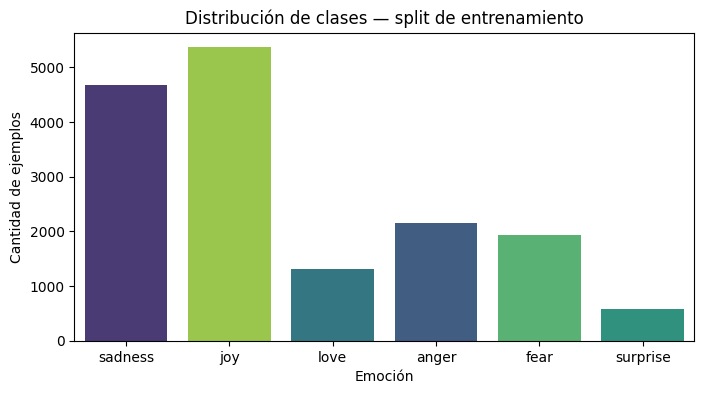

In [ ]:
train_df = dataset["train"].to_pandas()
train_df["label_name"] = train_df["label"].apply(lambda i: label_names[i])

plt.figure(figsize=(8, 4))
sns.countplot(data=train_df, x="label_name", order=label_names, hue="label_name", palette="viridis", legend=False)
plt.title("Distribución de clases — split de entrenamiento")
plt.xlabel("Emoción")
plt.ylabel("Cantidad de ejemplos")
plt.show()

## 5. Tokenización

Se usa el tokenizer de `bert-base-uncased`, que agrega automáticamente los tokens especiales `[CLS]` y `[SEP]`.

In [ ]:
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 64

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized_dataset = dataset.map(tokenize_batch, batched=True)
tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "token_type_ids", "label"],
)

tokenizer.convert_ids_to_tokens(tokenized_dataset["train"][0]["input_ids"])[:10]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

['[CLS]',
 'i',
 'didn',
 '##t',
 'feel',
 'humiliated',
 '[SEP]',
 '[PAD]',
 '[PAD]',
 '[PAD]']

## 6. Construcción de los DataLoaders

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(tokenized_dataset["train"], batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(tokenized_dataset["validation"], batch_size=BATCH_SIZE)
test_loader = DataLoader(tokenized_dataset["test"], batch_size=BATCH_SIZE)

next(iter(train_loader))["input_ids"].shape

torch.Size([32, 64])

## 7. Definición del modelo

BERT como encoder + capa lineal sobre el embedding de `[CLS]`. El softmax no se aplica en el forward: `CrossEntropyLoss` ya opera sobre logits, y el softmax se calcula aparte al momento de inferencia.

In [ ]:
class EmotionClassifier(nn.Module):
    def __init__(self, model_name, num_labels, dropout=0.1):
        super().__init__()
        #self.bert = AutoModel.from_pretrained(model_name)
        self.bert = AutoModel.from_pretrained(model_name, attn_implementation="eager") # se utiliza esta implementación para poder extraer los pesos de atención más adelante
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask, token_type_ids, output_attentions=False):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            output_attentions=output_attentions,
        )
        cls_output = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(self.dropout(cls_output))
        if output_attentions:
            return logits, outputs.attentions
        return logits

## 8. Configuración del entrenamiento

Optimizador `AdamW` (estándar para fine-tuning de BERT) con scheduler lineal y warmup.

In [ ]:
EPOCHS = 3
LEARNING_RATE = 2e-5

model = EmotionClassifier(MODEL_NAME, num_labels).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps,
)
criterion = nn.CrossEntropyLoss()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 9. Loop de entrenamiento

Se entrena y valida por época, guardando el mejor checkpoint según accuracy de validación.

In [ ]:
def run_epoch(model, loader, optimizer, scheduler, criterion, train):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    with torch.set_grad_enabled(train):
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            token_type_ids = batch["token_type_ids"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            logits = model(input_ids, attention_mask, token_type_ids)
            loss = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                scheduler.step()

            total_loss += loss.item()
            all_preds.extend(logits.argmax(dim=1).cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(loader)
    accuracy = (np.array(all_preds) == np.array(all_labels)).mean()
    return avg_loss, accuracy


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0
CHECKPOINT_PATH = "best_emotion_model.pt"

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(model, train_loader, optimizer, scheduler, criterion, train=True)
    val_loss, val_acc = run_epoch(model, val_loader, optimizer, scheduler, criterion, train=False)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CHECKPOINT_PATH)

    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

Epoch 1/3 | train_loss=0.6855 train_acc=0.7383 | val_loss=0.1842 val_acc=0.9280
Epoch 2/3 | train_loss=0.1457 train_acc=0.9379 | val_loss=0.1435 val_acc=0.9355
Epoch 3/3 | train_loss=0.0980 train_acc=0.9547 | val_loss=0.1353 val_acc=0.9355


## 10. Curvas de entrenamiento

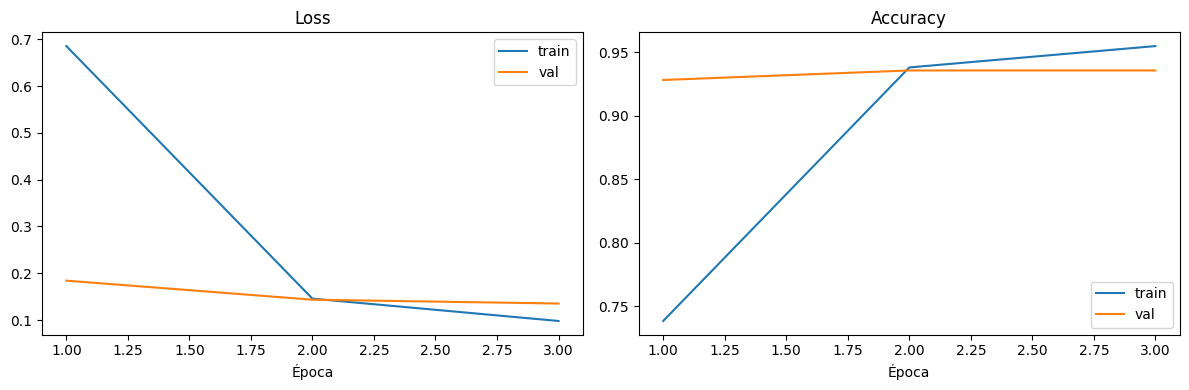

In [ ]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_range, history["train_loss"], label="train")
axes[0].plot(epochs_range, history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="train")
axes[1].plot(epochs_range, history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Evaluación sobre el test set

Se carga el mejor checkpoint guardado y se evalúa sobre el split de test.

In [ ]:
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()

test_preds, test_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        token_type_ids = batch["token_type_ids"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        logits = model(input_ids, attention_mask, token_type_ids)
        test_preds.extend(logits.argmax(dim=1).cpu().tolist())
        test_labels.extend(labels.cpu().tolist())

print(classification_report(test_labels, test_preds, target_names=label_names))

              precision    recall  f1-score   support

     sadness       0.97      0.95      0.96       581
         joy       0.93      0.97      0.95       695
        love       0.89      0.74      0.81       159
       anger       0.90      0.92      0.91       275
        fear       0.88      0.91      0.89       224
    surprise       0.79      0.73      0.76        66

    accuracy                           0.92      2000
   macro avg       0.89      0.87      0.88      2000
weighted avg       0.92      0.92      0.92      2000



## 12. Matriz de confusión

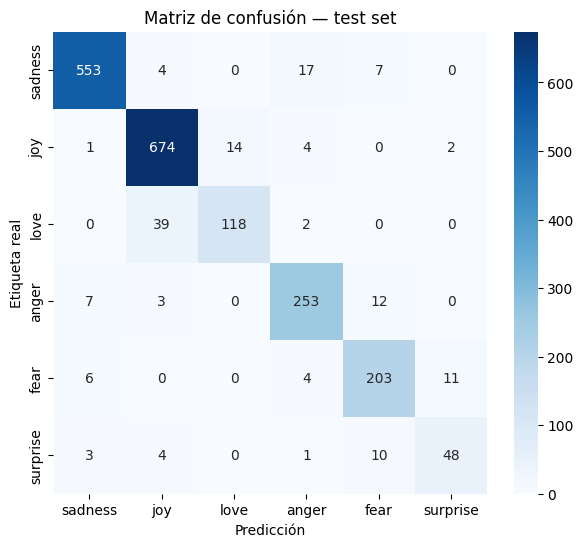

In [ ]:
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión — test set")
plt.show()

## 13. Extracción de cabezales de atención

Se extraen los pesos de atención de una oración de ejemplo y se grafica un cabezal puntual (capa, head).

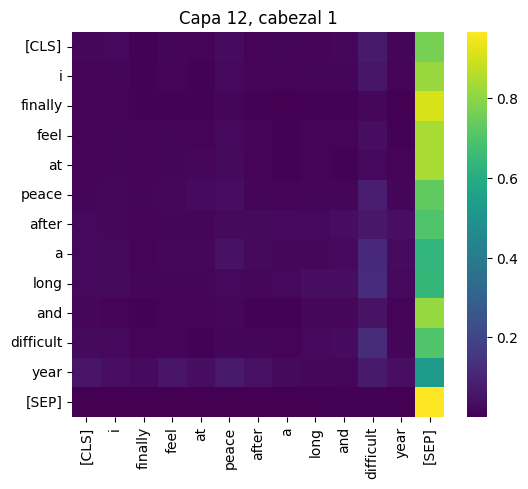

In [ ]:
def get_attentions(text):
    encoding = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH)
    encoding = {k: v.to(DEVICE) for k, v in encoding.items()}
    model.eval()
    with torch.no_grad():
        _, attentions = model(
            encoding["input_ids"],
            encoding["attention_mask"],
            encoding["token_type_ids"],
            output_attentions=True,
        )
    tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"][0].cpu())
    return attentions, tokens


def plot_attention_head(attentions, tokens, layer, head):
    attn = attentions[layer][0, head].cpu().numpy()
    plt.figure(figsize=(6, 5))
    sns.heatmap(attn, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
    plt.title(f"Capa {layer + 1}, cabezal {head + 1}")
    plt.xticks(rotation=90)
    plt.show()


sample_text = "I finally feel at peace after a long and difficult year"
attentions, tokens = get_attentions(sample_text)
plot_attention_head(attentions, tokens, layer=11, head=0)

## 14. Inferencia con frases nuevas

In [ ]:
def predict(text):
    encoding = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH)
    encoding = {k: v.to(DEVICE) for k, v in encoding.items()}
    model.eval()
    with torch.no_grad():
        logits = model(encoding["input_ids"], encoding["attention_mask"], encoding["token_type_ids"])
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_label = label_names[int(probs.argmax())]
    return pred_label, dict(zip(label_names, probs.round(4).tolist()))


sentences = [
    "I can't believe how happy I am right now",
    "I'm terrified of what might happen next",
    "This makes me so furious I could scream",
]

for sentence in sentences:
    label, probs = predict(sentence)
    print(f"{sentence!r} -> {label} | {probs}")

"I can't believe how happy I am right now" -> joy | {'sadness': 0.000699999975040555, 'joy': 0.9972000122070312, 'love': 0.000699999975040555, 'anger': 0.00039999998989515007, 'fear': 0.00019999999494757503, 'surprise': 0.0007999999797903001}
"I'm terrified of what might happen next" -> fear | {'sadness': 0.0017000000225380063, 'joy': 0.000699999975040555, 'love': 0.0003000000142492354, 'anger': 0.002199999988079071, 'fear': 0.9943000078201294, 'surprise': 0.0007999999797903001}
'This makes me so furious I could scream' -> anger | {'sadness': 0.00039999998989515007, 'joy': 0.0005000000237487257, 'love': 0.00019999999494757503, 'anger': 0.9950000047683716, 'fear': 0.003700000001117587, 'surprise': 0.00019999999494757503}
